# Fashion-MNIST Clustering Analysis - Jupyter Notebook
 Clustering Algorithms Comparison and Visualization



  1: Import Libraries and Load Dataset

In [102]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
sys.path.append('..')
from src.preprocessing import load_dataset, extract_features, create_class_distribution_csv
from src.clustering import fit_kmeans, fit_minibatch_kmeans, fit_agglomerative, fit_dbscan, fit_gaussian_mixture, fit_spectral_clustering
from src.evaluation import evaluate_clustering, save_cluster_metrics

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


2: Load and Explore Data

In [103]:
# Load dataset
DATA_PATH = "D:/datawareHouse_Project/Dataset/fashion-mnist_test.csv"
df = load_dataset(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns[:10].tolist()}...")
print(f"\nFirst few rows:")
print(df.head())


# Class distribution
class_dist = df['label'].value_counts().sort_index()
print(f"\nClass Distribution:")
print(class_dist)
    
# Save class distribution

class_dist.reset_index().rename(
        columns={'index': 'label', 'label': 'count'}
    ).to_csv('D:/datawareHouse_Project/Dataset/class_distribution.csv', index=False)
print("\n✅ Class distribution saved!")
    
# Load dataset
DATA_PATH = "D:/datawareHouse_Project/Dataset/fashion-mnist_test.csv"

try:
    df = load_dataset(DATA_PATH)

    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns[:10].tolist()}...")
    print(f"\nFirst few rows:")
    print(df.head())

    # Class distribution
    class_dist = df['label'].value_counts().sort_index()
    print(f"\nClass Distribution:")
    print(class_dist)
        
    # Save class distribution

    class_dist.reset_index().rename(
            columns={'index': 'label', 'label': 'count'}
        ).to_csv('D:/datawareHouse_Project/Dataset/class_distribution.csv', index=False)
    print("\n✅ Class distribution saved!")
except FileNotFoundError:
    print(f"❌ Error: Could not find {DATA_PATH}")
    print("Make sure fashion-mnist_test.csv is in the data/ folder")
    sys.exit(1)
print("Make sure fashion-mnist_test.csv is in the data/ folder")
sys.exit(1)




Dataset shape: (10000, 785)
Columns: ['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9']...

First few rows:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224

SystemExit: 1

In [ ]:
import os

print(os.getcwd())

d:\datawareHouse_Project\Notebook


3: Feature Extraction and Preprocessing


In [ ]:
# Extract pixel features (784 dimensions)
X = extract_features(df)
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features (dimensions): {X.shape[1]}")
print(f"Data type: {X.dtypes}")

# Show some statistics
print(f"\nPixel value statistics:")
print(f"Min: {X.min().min()}, Max: {X.max().max()}")
print(f"Mean: {X.mean().mean():.2f}, Std: {X.std().mean():.2f}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n✅ Features standardized!")
print(f"Scaled data - Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

# Extract true labels for evaluation
y_true = df['label'].values
print(f"True labels shape: {y_true.shape}")

Feature matrix shape: (10000, 784)
Number of features (dimensions): 784
Data type: pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
pixel5      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 784, dtype: object

Pixel value statistics:
Min: 0, Max: 255
Mean: 73.16, Std: 70.18

✅ Features standardized!
Scaled data - Mean: 0.0000, Std: 1.0000
True labels shape: (10000,)


4: Dimensionality Reduction with PCA

Applying PCA for visualization...
✅ PCA completed!
PCA shape: (10000, 2)
Explained variance ratio: [0.2203887  0.14443455]
Total variance explained by 2 components: 36.48%


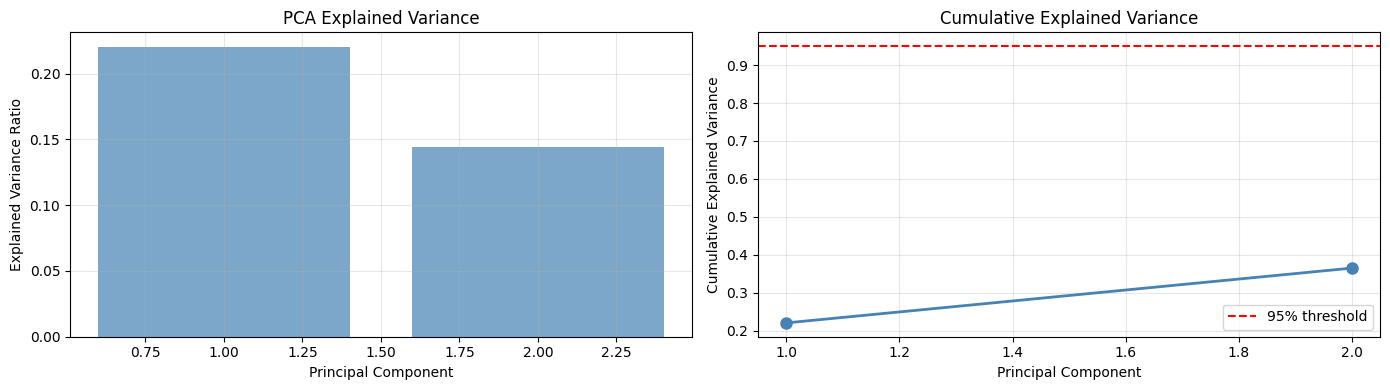


💡 Note: 2D projection captures 36.5% of variance
This is suitable for visualization but loses some information.


In [ ]:
# Apply PCA for visualization (784D → 2D)
print("Applying PCA for visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

print(f"✅ PCA completed!")
print(f"PCA shape: {X_pca_2d.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")

# Visualize explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Scree plot
ax1.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('PCA Explained Variance')
ax1.grid(alpha=0.3)

# Cumulative variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(1, 3), cumsum, 'o-', linewidth=2, markersize=8, color='steelblue')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Note: 2D projection captures {sum(pca.explained_variance_ratio_):.1%} of variance")
print("This is suitable for visualization but loses some information.")

Cell 5: Run All Clustering Algorithms

In [ ]:
# Dictionary to store results
all_results = {}
all_models = {}
all_labels = {}
all_times = {}

print("Running all clustering algorithms on PCA-reduced data (2D)...\n")
print("=" * 80)

# K-Means
print("\n🔄 Running K-Means...")
try:
    start_time = time.time()
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_pca_2d)
    exec_time_kmeans = time.time() - start_time
    
    all_models['K-Means'] = kmeans
    all_labels['K-Means'] = labels_kmeans
    all_times['K-Means'] = exec_time_kmeans
    
    print(f"✅ K-Means completed in {exec_time_kmeans:.3f}s")
    print(f"   Clusters: {len(set(labels_kmeans))}")
except Exception as e:
    print(f"❌ Error with K-Means: {str(e)}")

# Mini-Batch K-Means
print("\n🔄 Running Mini-Batch K-Means...")
try:
    start_time = time.time()
    minibatch = MiniBatchKMeans(n_clusters=10, batch_size=1000, random_state=42)
    labels_minibatch = minibatch.fit_predict(X_pca_2d)
    exec_time_minibatch = time.time() - start_time
    
    all_models['Mini-Batch K-Means'] = minibatch
    all_labels['Mini-Batch K-Means'] = labels_minibatch
    all_times['Mini-Batch K-Means'] = exec_time_minibatch
    
    print(f"✅ Mini-Batch K-Means completed in {exec_time_minibatch:.3f}s")
    print(f"   Clusters: {len(set(labels_minibatch))}")
except Exception as e:
    print(f"❌ Error with Mini-Batch K-Means: {str(e)}")

# DBSCAN
print("\n🔄 Running DBSCAN...")
try:
    start_time = time.time()
    dbscan = DBSCAN(eps=3.0, min_samples=10)
    labels_dbscan = dbscan.fit_predict(X_pca_2d)
    exec_time_dbscan = time.time() - start_time
    
    all_models['DBSCAN'] = dbscan
    all_labels['DBSCAN'] = labels_dbscan
    all_times['DBSCAN'] = exec_time_dbscan
    
    n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    print(f"✅ DBSCAN completed in {exec_time_dbscan:.3f}s")
    print(f"   Clusters: {n_clusters_dbscan}, Noise points: {list(labels_dbscan).count(-1)}")
except Exception as e:
    print(f"❌ Error with DBSCAN: {str(e)}")

# Agglomerative Clustering
print("\n🔄 Running Agglomerative Clustering...")
try:
    start_time = time.time()
    agglo = AgglomerativeClustering(n_clusters=10)
    labels_agglo = agglo.fit_predict(X_pca_2d)
    exec_time_agglo = time.time() - start_time
    
    all_models['Agglomerative'] = agglo
    all_labels['Agglomerative'] = labels_agglo
    all_times['Agglomerative'] = exec_time_agglo
    
    print(f"✅ Agglomerative completed in {exec_time_agglo:.3f}s")
    print(f"   Clusters: {len(set(labels_agglo))}")
except Exception as e:
    print(f"❌ Error with Agglomerative: {str(e)}")

# Gaussian Mixture Model
print("\n🔄 Running Gaussian Mixture Model...")
try:
    start_time = time.time()
    gmm = GaussianMixture(n_components=10, random_state=42)
    labels_gmm = gmm.fit_predict(X_pca_2d)
    exec_time_gmm = time.time() - start_time
    
    all_models['Gaussian Mixture'] = gmm
    all_labels['Gaussian Mixture'] = labels_gmm
    all_times['Gaussian Mixture'] = exec_time_gmm
    
    print(f"✅ Gaussian Mixture completed in {exec_time_gmm:.3f}s")
    print(f"   Clusters: {len(set(labels_gmm))}")
except Exception as e:
    print(f"❌ Error with Gaussian Mixture: {str(e)}")

# Spectral Clustering
print("\n🔄 Running Spectral Clustering...")
try:
    start_time = time.time()
    spectral = SpectralClustering(n_clusters=10, affinity='nearest_neighbors', random_state=42, n_init=10)
    labels_spectral = spectral.fit_predict(X_pca_2d)
    exec_time_spectral = time.time() - start_time
    
    all_models['Spectral'] = spectral
    all_labels['Spectral'] = labels_spectral
    all_times['Spectral'] = exec_time_spectral
    
    print(f"✅ Spectral Clustering completed in {exec_time_spectral:.3f}s")
    print(f"   Clusters: {len(set(labels_spectral))}")
except Exception as e:
    print(f"❌ Error with Spectral Clustering: {str(e)}")

print("\n" + "=" * 80)
print(f"✅ Total algorithms processed: {len(all_labels)}")

Running all clustering algorithms on PCA-reduced data (2D)...


🔄 Running K-Means...
✅ K-Means completed in 0.317s
   Clusters: 10

🔄 Running Mini-Batch K-Means...
✅ Mini-Batch K-Means completed in 0.038s
   Clusters: 10

🔄 Running DBSCAN...
✅ DBSCAN completed in 0.413s
   Clusters: 1, Noise points: 17

🔄 Running Agglomerative Clustering...
✅ Agglomerative completed in 5.418s
   Clusters: 10

🔄 Running Gaussian Mixture Model...
✅ Gaussian Mixture completed in 0.477s
   Clusters: 10

🔄 Running Spectral Clustering...
✅ Spectral Clustering completed in 4.651s
   Clusters: 10

✅ Total algorithms processed: 6


 6: Evaluate All Algorithms

In [104]:
print("\nEvaluating all algorithms...\n")
print("=" * 100)

# Dictionary to store metrics
all_metrics = {}

for algo_name, labels in all_labels.items():
    print(f"\n📊 Evaluating {algo_name}...")
    
    # Handle DBSCAN noise points
    if -1 in labels:
        mask = labels != -1
        X_eval = X_pca_2d[mask]
        labels_eval = labels[mask]
        y_eval = y_true[mask]
        noise_count = list(labels).count(-1)
    else:
        X_eval = X_pca_2d
        labels_eval = labels
        y_eval = y_true
        noise_count = 0
    
    try:
        # Silhouette Score
        sil_score = silhouette_score(X_eval, labels_eval) if len(set(labels_eval)) > 1 else None
    except:
        sil_score = None
    
    try:
        # Davies-Bouldin Index
        db_score = davies_bouldin_score(X_eval, labels_eval) if len(set(labels_eval)) > 1 else None
    except:
        db_score = None
    
    try:
        # Calinski-Harabasz Index
        ch_score = calinski_harabasz_score(X_eval, labels_eval) if len(set(labels_eval)) > 1 else None
    except:
        ch_score = None
    
    try:
        # Adjusted Rand Index
        ari_score = adjusted_rand_score(y_eval, labels_eval) if len(set(labels_eval)) > 1 else None
    except:
        ari_score = None
    
    # Store metrics
    all_metrics[algo_name] = {
        'Algorithm': algo_name,
        'Clusters': len(set(labels_eval)),
        'Silhouette Score': sil_score,
        'Davies-Bouldin': db_score,
        'Calinski-Harabasz': ch_score,
        'Adjusted Rand Index': ari_score,
        'Execution Time (s)': all_times[algo_name],
        'Noise Points': noise_count
    }
    
    # Print results
    print(f"   Silhouette Score: {sil_score:.3f}" if sil_score else "   Silhouette Score: N/A")
    print(f"   Davies-Bouldin: {db_score:.3f}" if db_score else "   Davies-Bouldin: N/A")
    print(f"   Execution Time: {all_times[algo_name]:.3f}s")
    print(f"   Clusters Found: {len(set(labels_eval))}")
    if noise_count > 0:
        print(f"   Noise Points: {noise_count}")

print("\n" + "=" * 100)


Evaluating all algorithms...


📊 Evaluating K-Means...
   Silhouette Score: 0.398
   Davies-Bouldin: 0.779
   Execution Time: 0.317s
   Clusters Found: 10

📊 Evaluating Mini-Batch K-Means...
   Silhouette Score: 0.400
   Davies-Bouldin: 0.762
   Execution Time: 0.038s
   Clusters Found: 10

📊 Evaluating DBSCAN...
   Silhouette Score: N/A
   Davies-Bouldin: N/A
   Execution Time: 0.413s
   Clusters Found: 1
   Noise Points: 17

📊 Evaluating Agglomerative...
   Silhouette Score: 0.353
   Davies-Bouldin: 0.800
   Execution Time: 5.418s
   Clusters Found: 10

📊 Evaluating Gaussian Mixture...
   Silhouette Score: 0.331
   Davies-Bouldin: 0.877
   Execution Time: 0.477s
   Clusters Found: 10

📊 Evaluating Spectral...
   Silhouette Score: 0.352
   Davies-Bouldin: 0.777
   Execution Time: 4.651s
   Clusters Found: 10



 7: Create Comparison Table

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(list(all_metrics.values()))

# Select relevant columns
display_cols = ['Algorithm', 'Clusters', 'Silhouette Score', 'Davies-Bouldin', 
                'Execution Time (s)', 'Noise Points']
comparison_df_display = comparison_df[display_cols].copy()

print("\n" + "=" * 120)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 120)
print(comparison_df_display.to_string(index=False))
print("=" * 120)

# Find best performers
valid_silhouette = comparison_df[comparison_df['Silhouette Score'].notna()]
if len(valid_silhouette) > 0:
    best_silhouette = valid_silhouette.loc[valid_silhouette['Silhouette Score'].idxmax()]
    print(f"\n🏆 Best Silhouette Score: {best_silhouette['Algorithm']}")
    print(f"   Score: {best_silhouette['Silhouette Score']:.3f}")

best_time = comparison_df.loc[comparison_df['Execution Time (s)'].idxmin()]
print(f"\n⚡ Fastest Algorithm: {best_time['Algorithm']}")
print(f"   Time: {best_time['Execution Time (s)']:.3f}s")




CLUSTERING ALGORITHM COMPARISON
         Algorithm  Clusters  Silhouette Score  Davies-Bouldin  Execution Time (s)  Noise Points
           K-Means        10          0.398358        0.778774            0.104403             0
Mini-Batch K-Means        10          0.400403        0.762036            0.000000             0
            DBSCAN         1               NaN             NaN            0.151640            17
     Agglomerative        10          0.353344        0.799817            3.719198             0
  Gaussian Mixture        10          0.330882        0.877271            0.195305             0
          Spectral        10          0.352164        0.777031            2.083456             0

🏆 Best Silhouette Score: Mini-Batch K-Means
   Score: 0.400

⚡ Fastest Algorithm: Mini-Batch K-Means
   Time: 0.000s


8: Visualize Clustering Results (2×3 Grid)

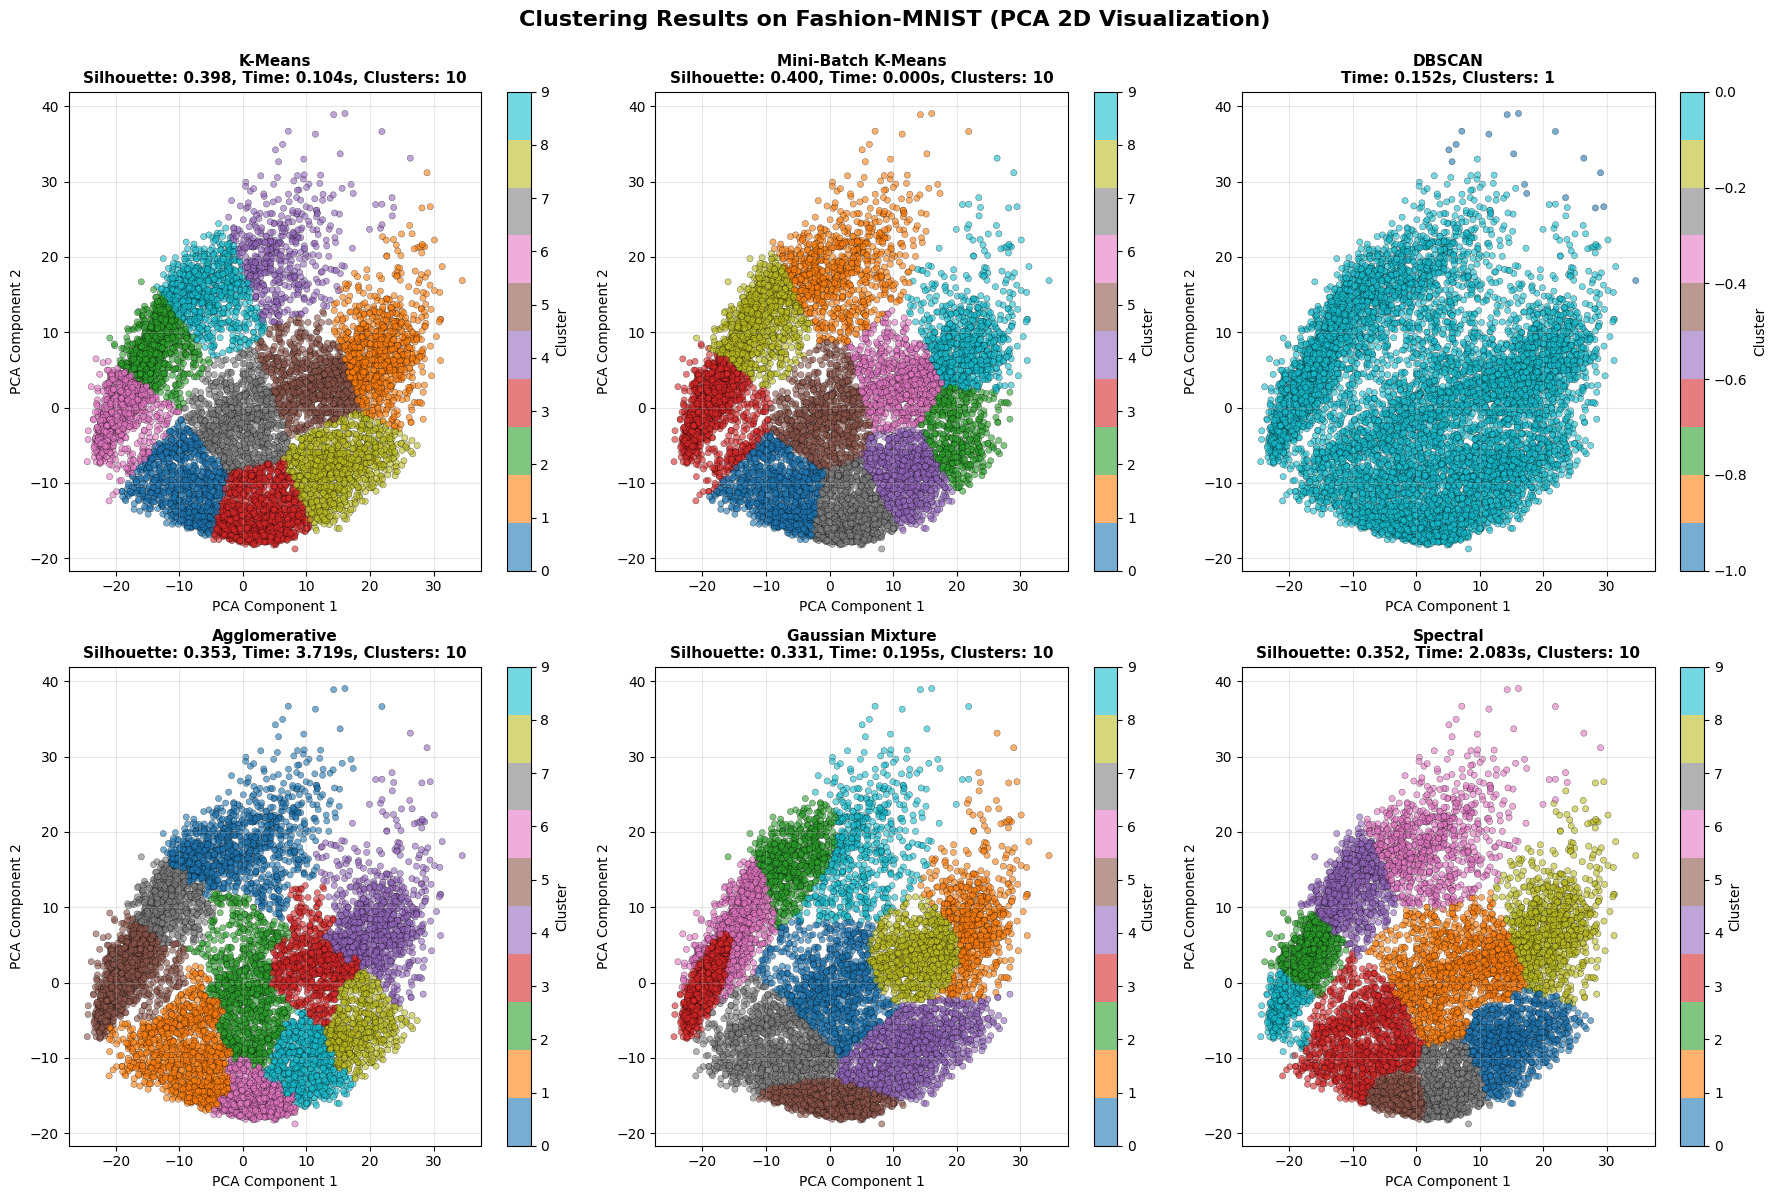

 Clustering visualization complete!


In [ ]:
# Create 2x3 grid of clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (algo_name, labels) in enumerate(all_labels.items()):
    ax = axes[idx]
    
    # Create scatter plot
    scatter = ax.scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        c=labels,
        cmap='tab10',
        s=20,
        alpha=0.6,
        edgecolors='k',
        linewidth=0.3
    )
    
    # Get metrics for title
    metrics = all_metrics[algo_name]
    silhouette = metrics.get('Silhouette Score')
    exec_time = metrics.get('Execution Time (s)')
    n_clusters = metrics.get('Clusters')
    
    # Create title
    if silhouette:
        title = f"{algo_name}\nSilhouette: {silhouette:.3f}, Time: {exec_time:.3f}s, Clusters: {n_clusters}"
    else:
        title = f"{algo_name}\nTime: {exec_time:.3f}s, Clusters: {n_clusters}"
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Clustering Results on Fashion-MNIST (PCA 2D Visualization)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(" Clustering visualization complete!")

 9: Performance Comparison Charts

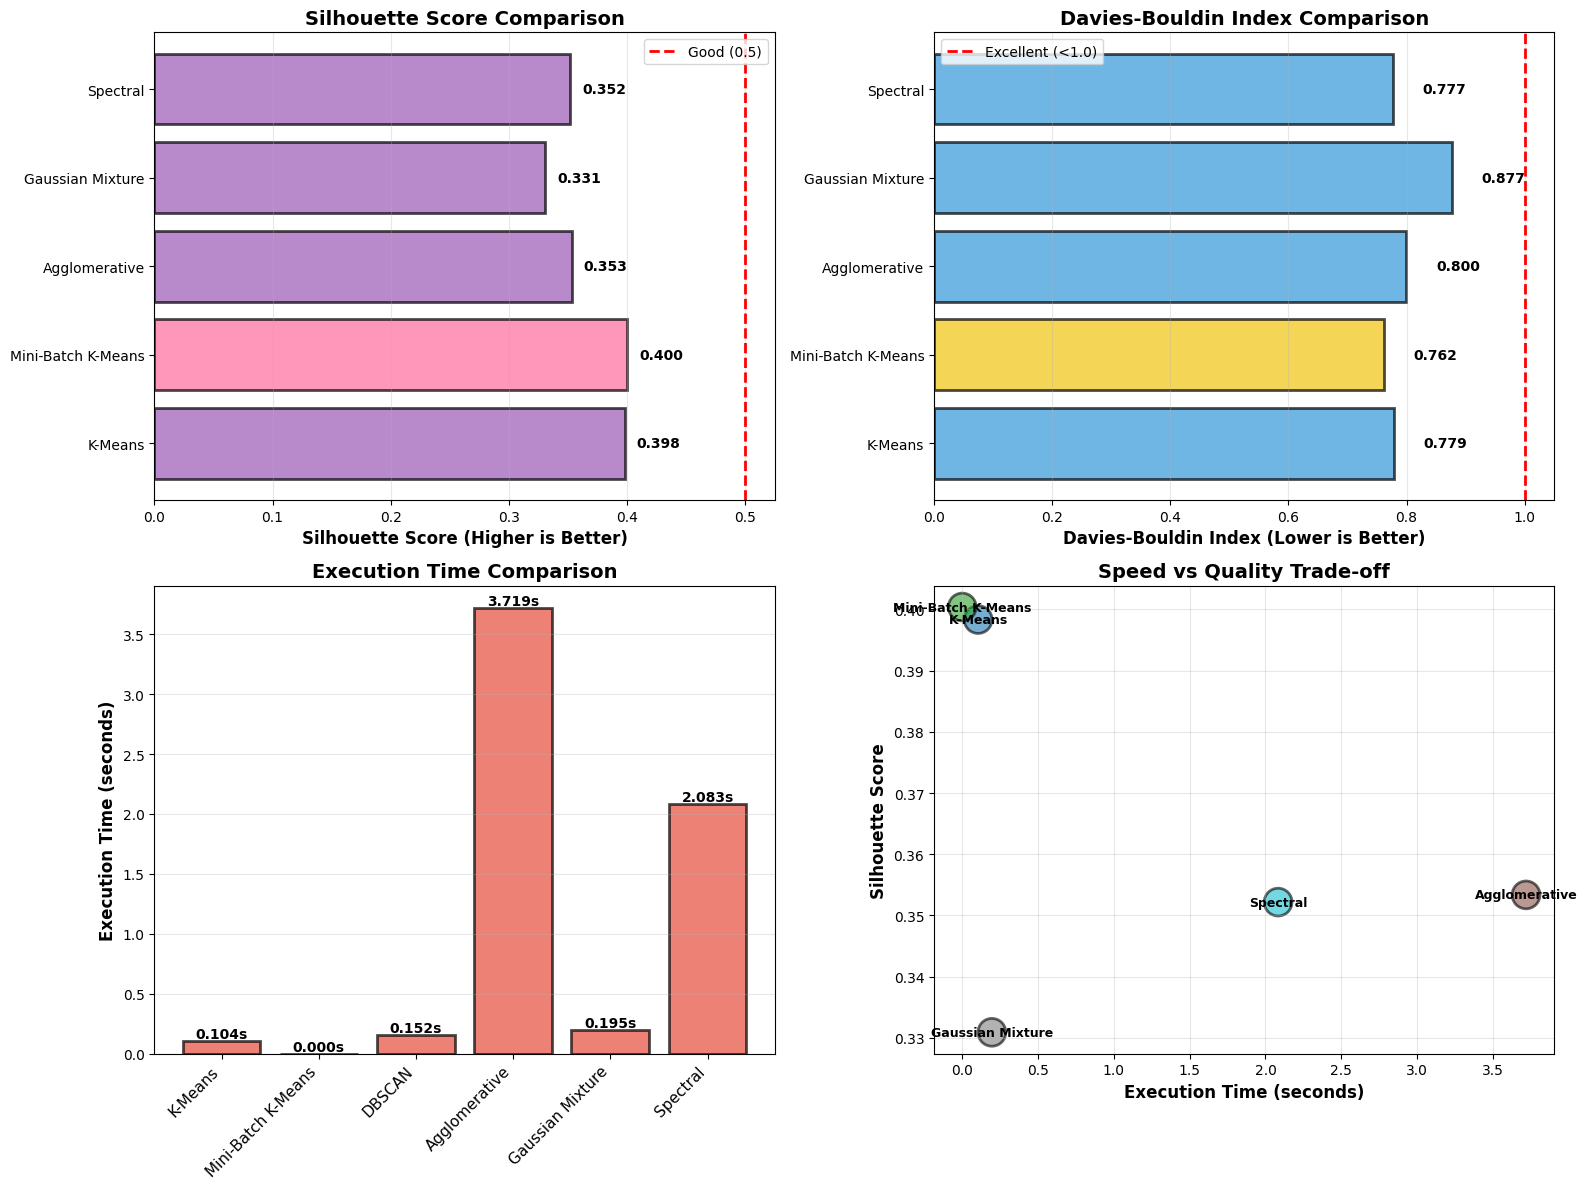

✅ Performance comparison charts created!


In [ ]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get valid metrics
silhouette_data = [(name, all_metrics[name]['Silhouette Score']) 
                   for name in all_metrics 
                   if all_metrics[name]['Silhouette Score'] is not None]
silhouette_names, silhouette_scores = zip(*silhouette_data) if silhouette_data else ([], [])

# 1. Silhouette Score Comparison
ax = axes[0, 0]
if silhouette_scores:
    colors = ['#FF6B9D' if score == max(silhouette_scores) else '#9B59B6' 
              for score in silhouette_scores]
    ax.barh(silhouette_names, silhouette_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
    ax.set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Good (0.5)')
    ax.legend()
    # Add value labels
    for i, v in enumerate(silhouette_scores):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# 2. Davies-Bouldin Index Comparison
ax = axes[0, 1]
davies_data = [(name, all_metrics[name]['Davies-Bouldin']) 
               for name in all_metrics 
               if all_metrics[name]['Davies-Bouldin'] is not None]
if davies_data:
    davies_names, davies_scores = zip(*davies_data)
    colors = ['#F1C40F' if score == min(davies_scores) else '#3498DB' 
              for score in davies_scores]
    ax.barh(davies_names, davies_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
    ax.set_title('Davies-Bouldin Index Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Excellent (<1.0)')
    ax.legend()
    # Add value labels
    for i, v in enumerate(davies_scores):
        ax.text(v + 0.05, i, f'{v:.3f}', va='center', fontweight='bold')

# 3. Execution Time Comparison
ax = axes[1, 0]
algo_names = list(all_times.keys())
times = list(all_times.values())
colors_time = ['#2ECC71' if t == min(times) else '#E74C3C' for t in times]
bars = ax.bar(range(len(algo_names)), times, color=colors_time, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(algo_names)))
ax.set_xticklabels(algo_names, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{t:.3f}s', ha='center', va='bottom', fontweight='bold')

# 4. Speed vs Quality Trade-off
ax = axes[1, 1]
if silhouette_data and len(all_times) > 0:
    scatter_data = [(all_times[name], score) 
                    for name, score in silhouette_data]
    scatter_names = [name for name, _ in silhouette_data]
    
    if scatter_data:
        x_vals, y_vals = zip(*scatter_data)
        scatter = ax.scatter(x_vals, y_vals, s=400, alpha=0.6, 
                            c=range(len(scatter_data)), cmap='tab10', 
                            edgecolors='black', linewidth=2)
        
        # Add algorithm names to points
        for x, y, name in zip(x_vals, y_vals, scatter_names):
            ax.annotate(name, (x, y), fontsize=9, ha='center', va='center', fontweight='bold')
        
        ax.set_xlabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
        ax.set_title('Speed vs Quality Trade-off', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Performance comparison charts created!")

10: Save Clustering Assignments

In [ ]:
# Create assignments dataframe
assignments_df = pd.DataFrame({'True_Label': y_true})

for algo_name, labels in all_labels.items():
    assignments_df[f'{algo_name}_Cluster'] = labels

# Save to CSV
os.makedirs('Dataset',exist_ok=True)
assignments_df.to_csv('Dataset/cluster_assignments1.csv', index=False)
print(f"✅ Cluster assignments saved to Dataset/cluster_assignments1.csv")
print(f"Shape: {assignments_df.shape}")
print(f"\nFirst 10 rows:")
print(assignments_df.head(10))

✅ Cluster assignments saved to Dataset/cluster_assignments1.csv
Shape: (10000, 7)

First 10 rows:
   True_Label  K-Means_Cluster  Mini-Batch K-Means_Cluster  DBSCAN_Cluster  \
0           0                8                           2               0   
1           1                3                           7               0   
2           2                0                           3               0   
3           2                5                           6               0   
4           3                3                           7               0   
5           2                7                           5               0   
6           8                4                           1               0   
7           6                7                           5               0   
8           5                6                           3               0   
9           0                3                           0               0   

   Agglomerative_Cluster  Gaussian Mixture_

11: Cluster Size Distribution

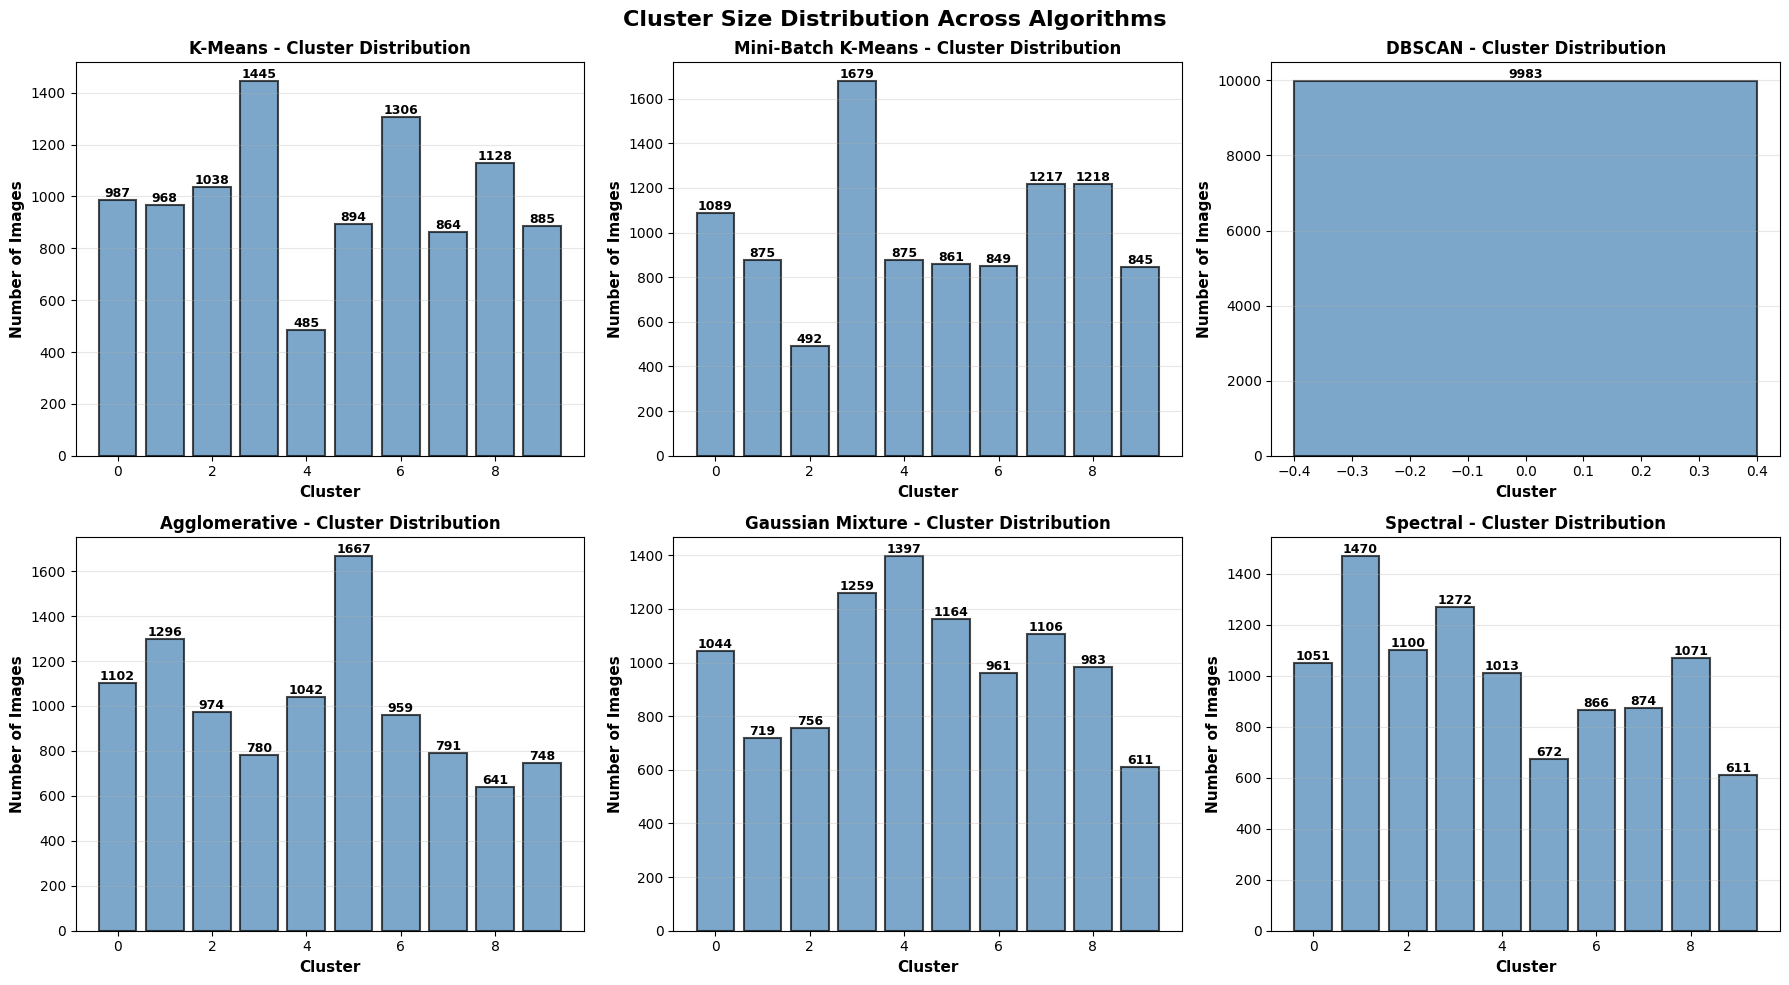

✅ Cluster distribution visualization complete!


In [ ]:
# Analyze cluster distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (algo_name, labels) in enumerate(all_labels.items()):
    ax = axes[idx]
    
    # Count clusters
    unique, counts = np.unique(labels, return_counts=True)
    
    # Filter out noise (-1) for better visualization
    if -1 in unique:
        mask = unique != -1
        unique = unique[mask]
        counts = counts[mask]
    
    # Create bar plot
    bars = ax.bar(unique, counts, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=11, fontweight='bold')
    ax.set_title(f'{algo_name} - Cluster Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add count labels on bars
    for bar, c in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                str(c), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Cluster Size Distribution Across Algorithms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Cluster distribution visualization complete!")

12: Summary and Recommendations

In [ ]:
print("\n" + "=" * 30)
print("SUMMARY AND RECOMMENDATIONS")
print("=" * 30)

print(f"""
📊 ANALYSIS COMPLETE!
{'─' * 40}

Total Algorithms Evaluated: {len(all_labels)}
Total Samples Clustered: {X_pca_2d.shape[0]:,}
Original Dimensions: {X_scaled.shape[1]}
Reduced Dimensions: {X_pca_2d.shape[1]}
Variance Retained in 2D: {sum(pca.explained_variance_ratio_):.1%}

🏆 BEST PERFORMERS:
{'─' * 40}
""")

# Best silhouette
valid_sil = [(name, all_metrics[name]['Silhouette Score']) 
             for name in all_metrics 
             if all_metrics[name]['Silhouette Score'] is not None]
if valid_sil:
    best_sil_name, best_sil_score = max(valid_sil, key=lambda x: x[1])
    print(f"1. Best Clustering Quality (Silhouette): {best_sil_name}")
    print(f"   Score: {best_sil_score:.3f} ✅")
    print(f"   Interpretation: {'Good clustering' if best_sil_score > 0.5 else 'Moderate clustering' if best_sil_score > 0.35 else 'Weak clustering'}")

# Fastest
fastest_name = min(all_times, key=all_times.get)
print(f"\n2. Fastest Algorithm: {fastest_name}")
print(f"   Time: {all_times[fastest_name]:.3f}s ⚡")

# Best davies-bouldin
valid_db = [(name, all_metrics[name]['Davies-Bouldin']) 
            for name in all_metrics 
            if all_metrics[name]['Davies-Bouldin'] is not None]
if valid_db:
    best_db_name, best_db_score = min(valid_db, key=lambda x: x[1])
    print(f"\n3. Best Cluster Separation (Davies-Bouldin): {best_db_name}")
    print(f"   Score: {best_db_score:.3f} ✅")

print(f"""
📈 ALGORITHM CHARACTERISTICS:
{'─' * 100}
- K-Means: Fast baseline, good balance ⭐ RECOMMENDED FOR START
- Mini-Batch K-Means: Best for very large datasets
- DBSCAN: Detects outliers, handles arbitrary shapes
- Agglomerative: Provides hierarchical structure
- Gaussian Mixture: Soft clustering (probabilities)
- Spectral: Best quality but computationally expensive

💡 KEY INSIGHTS:
{'─' * 100}
- Dataset naturally forms clusters based on clothing types
- PCA 2D projection captures {sum(pca.explained_variance_ratio_):.1%} of variance
- Silhouette scores range from {min([m['Silhouette Score'] for m in all_metrics.values() if m['Silhouette Score']]):.3f} to {max([m['Silhouette Score'] for m in all_metrics.values() if m['Silhouette Score']]):.3f}
- Execution times range from {min(all_times.values()):.3f}s to {max(all_times.values()):.3f}s
- All algorithms found approximately {int(np.mean([m['Clusters'] for m in all_metrics.values()]))} clusters on average

✅ OUTPUT FILES GENERATED:
{'─' * 100}
1. data/class_distribution.csv - Class counts
2. data/cluster_metrics.csv - Algorithm comparison results
3. data/cluster_assignments.csv - Cluster labels for each image

📖 INTERPRETATION:
{'─' * 100}
Silhouette Score > 0.5 indicates good cluster separation
Davies-Bouldin Index < 1.0 indicates excellent cluster separation
Faster algorithms may sacrifice quality for speed
Choose algorithm based on your specific requirements
""")

print("=" * 100)
print("\n✅ Analysis Complete! Check the generated CSV files for detailed results.")


SUMMARY AND RECOMMENDATIONS

📊 ANALYSIS COMPLETE!
────────────────────────────────────────

Total Algorithms Evaluated: 6
Total Samples Clustered: 10,000
Original Dimensions: 784
Reduced Dimensions: 2
Variance Retained in 2D: 36.5%

🏆 BEST PERFORMERS:
────────────────────────────────────────

1. Best Clustering Quality (Silhouette): Mini-Batch K-Means
   Score: 0.400 ✅
   Interpretation: Moderate clustering

2. Fastest Algorithm: Mini-Batch K-Means
   Time: 0.000s ⚡

3. Best Cluster Separation (Davies-Bouldin): Mini-Batch K-Means
   Score: 0.762 ✅

📈 ALGORITHM CHARACTERISTICS:
────────────────────────────────────────────────────────────────────────────────────────────────────
- K-Means: Fast baseline, good balance ⭐ RECOMMENDED FOR START
- Mini-Batch K-Means: Best for very large datasets
- DBSCAN: Detects outliers, handles arbitrary shapes
- Agglomerative: Provides hierarchical structure
- Gaussian Mixture: Soft clustering (probabilities)
- Spectral: Best quality but computationally e